In [10]:
import pandas as pd

original_data = pd.read_csv("original_data/parco-circolante-veicoli.csv", delimiter=";")
original_data

,Anno,CAP,totale_veicoli,BENZINA,BENZINA E GAS LIQUIDO,BENZINA E METANO,ELETTRICITA,GASOLIO,IBRIDO BENZINA,IBRIDO GASOLIO,...,SRLS,ANZIANITÀ VEICOLO 0 - 1 ANNI,ANZIANITÀ VEICOLO 2 – 3 ANNI,ANZIANITÀ VEICOLO 4 – 5 ANNI,ANZIANITÀ VEICOLO 6 – 7 ANNI,ANZIANITÀ VEICOLO 8 – 9 ANNI,ANZIANITÀ VEICOLO 10 - 12 ANNI,ANZIANITÀ VEICOLO 13 - 15 ANNI,ANZIANITÀ VEICOLO OLTRE 15 ANNI,ANZIANITÀ VEICOLO NON DEFINITO
0,2020,40125,5198,2636,348,176,13.0,1723,264.0,13.0,...,NaN,598.0,663.0,588.0,418.0,431.0,681.0,554.0,1262,3
1,2020,40137,12610,6201,1163,550,22.0,3778,772.0,29.0,...,1.0,1543.0,1758.0,1563.0,1141.0,1089.0,1726.0,1435.0,2352,3
2,2021,40124,4271,2094,332,223,19.0,1258,274.0,38.0,...,6.0,452.0,550.0,522.0,407.0,265.0,537.0,471.0,1064,3
3,2021,40126,5405,2497,481,222,22.0,1724,379.0,33.0,...,1.0,558.0,688.0,627.0,441.0,402.0,689.0,629.0,1366,5
4,2022,40121,4143,1813,321,163,34.0,1354,349.0,55.0,...,19.0,471.0,513.0,530.0,410.0,285.0,397.0,447.0,1084,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2023,40126,5381,2425,473,207,43.0,1534,580.0,73.0,...,9.0,562.0,550.0,615.0,563.0,394.0,552.0,578.0,1562,5
116,2023,40136,5330,2432,300,131,108.0,1493,748.0,86.0,...,2.0,550.0,687.0,733.0,615.0,438.0,490.0,487.0,1327,3
117,2023,40138,19746,7782,2211,919,324.0,5722,2102.0,432.0,...,58.0,2480.0,2207.0,2415.0,2218.0,1611.0,1950.0,2163.0,4699,3
118,2024,40128,19325,7301,2485,940,477.0,5622,2150.0,127.0,...,163.0,1932.0,1935.0,2058.0,2176.0,1812.0,1920.0,2226.0,5261,5


In [13]:
# Sum the values in 'ELETTRICITA' for each unique 'Anno'
electricity_sum_by_year = original_data.groupby('Anno')['ELETTRICITA'].sum()
electricity_sum_by_year

Anno
2019     191.0
2020     421.0
2021     927.0
2022    1108.0
2023    1645.0
2024    2373.0
Name: ELETTRICITA, dtype: float64

In [14]:
# Sum the values in 'totale_veicoli' for each unique 'Anno'
total_vehicles_by_year = original_data.groupby('Anno')['totale_veicoli'].sum()
total_vehicles_by_year

Anno
2019    208487
2020    207780
2021    206162
2022    206985
2023    208649
2024    210373
Name: totale_veicoli, dtype: int64

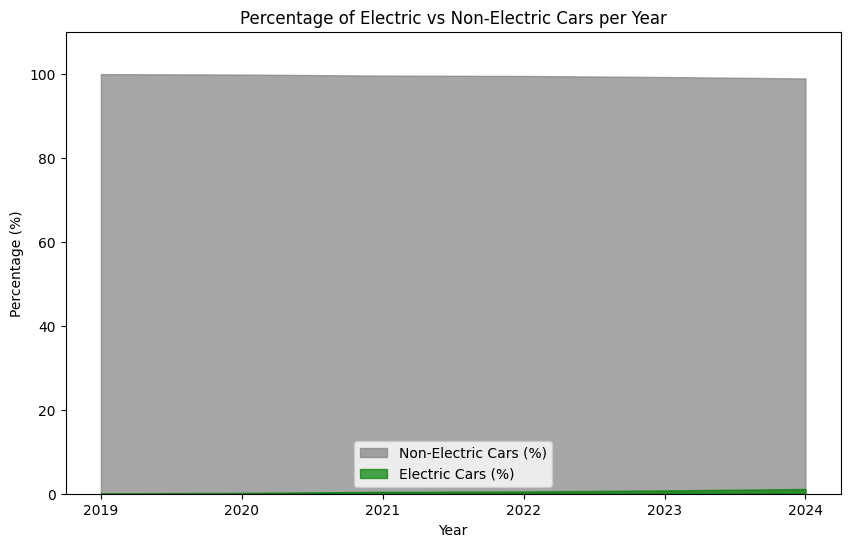

In [25]:
# Area chart: percentage of electric cars and non-electric cars per year
import matplotlib.pyplot as plt
percentage_electric = (electricity_sum_by_year / total_vehicles_by_year) * 100
percentage_nonelectric = 100 - percentage_electric
plt.figure(figsize=(10, 6))
plt.fill_between(percentage_electric.index, percentage_nonelectric.values, alpha=0.7, color="gray", label="Non-Electric Cars (%)")
plt.fill_between(percentage_electric.index, percentage_electric.values, alpha=0.7, color="green", label="Electric Cars (%)")
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Percentage of Electric vs Non-Electric Cars per Year')
plt.ylim(0, 110)
plt.legend()
plt.show()

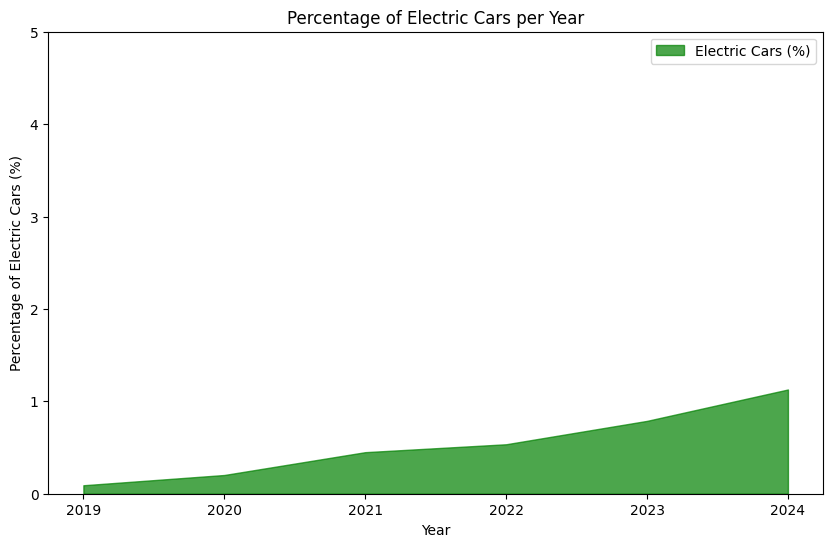

In [26]:
# Area chart: percentage of electric cars per year
percentage_electric = (electricity_sum_by_year / total_vehicles_by_year) * 100
plt.figure(figsize=(10,6))
plt.fill_between(percentage_electric.index, percentage_electric.values, alpha=0.7, color='green', label='Electric Cars (%)')
plt.xlabel('Year')
plt.ylabel('Percentage of Electric Cars (%)')
plt.title('Percentage of Electric Cars per Year')
plt.ylim(0, 5)
plt.legend()
plt.show()

In [30]:
# Convert percentage_electric Series to DataFrame and rename column for CSV export
percentage_electric_df = percentage_electric.to_frame()
percentage_electric_df = percentage_electric_df.rename(columns={percentage_electric_df.columns[0]: "percentage"})
percentage_electric_df.to_csv("electric.csv")